# 🧠🤖 第1周·Day 2 | Multi-Head Attention 与位置编码

> **🔄 昨日复习**：
> - Self-Attention 核心：每个词通过 Q/K/V 机制"看"所有其他词
> - Q·K 点积 → softmax → 对 V 加权求和
> - 本质：每个词的输出 = 所有词信息的加权融合
>
> **今日目标**：理解多头注意力和位置编码——Transformer 的两个关键组件。

---

## 📝 核心知识点

### 🔄 多头注意力 = 多个"注意力"并行工作

- 昨天的 Self-Attention 只有1组 Q/K/V
- 多头注意力拆成多组（比如8个"头"），每组独立计算
- 每个头关注不同模式——有的抓语法，有的抓语义，有的关注邻近词
- 最后拼接所有头的输出，再过一次线性投影

> 类比：一个人看文章只关注一个角度，8个人同时看各自的角度，合起来就全面了

### 📐 位置编码：让模型知道词的顺序

- Self-Attention 本身没顺序概念——"我爱你"和"你爱我"算出来一样
- 位置编码给每个位置一个独特向量，加到词向量上
- 原始 Transformer 用正弦/余弦编码（sinusoidal）

## 💡 关键公式

**头数量关系**：
```
d_model = num_heads × head_dim
```
例如：d_model=512, 8头 → 每个头维度=64

**位置编码**：
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
```
每个位置、每个维度都有一个确定的正弦/余弦值。

## 🔑 英文术语

- **Multi-Head Attention** [ˌmʌlti hɛd əˈtɛnʃən] 多头注意力
- **Concatenation** [kənˌkætəˈneɪʃən] 拼接
- **Positional Encoding** [pəˈzɪʃənəl ɪnˈkoʊdɪŋ] 位置编码
- **Sinusoidal** [ˌsaɪnəˈsɔɪdəl] 正弦余弦的
- **Projection** [prəˈdʒɛkʃən] 投影（Q/K/V的线性变换）

## 🎬 推荐视频

> ⭐ **首选**: 3Blue1Brown - 直观解释注意力机制（后半段图解多头注意力，可视化无敌）
> https://www.bilibili.com/video/BV1TZ421j7Ke/

> 📺 **备选**: 15分钟认识注意力·多头注意力（B站）
> https://www.bilibili.com/video/BV17x8jzvEm6/

> 🎓 **进阶**: 李沐 - Transformer 论文精读（逐行讲 Multi-Head Attention 和 Positional Encoding）
> https://www.bilibili.com/video/BV1pu411o7BE/

📖 **延伸阅读**：

> ⭐ **首选**: Jay Alammar - The Illustrated Transformer（用动画 GIF 展示 8 个头并行计算）
> https://jalammar.github.io/illustrated-transformer/

> 📐 **位置编码**: Kazemnejad - Transformer Positional Encoding 详解（公式拆解 + 可视化）
> https://kazemnejad.com/blog/transformer_architecture_positional_encoding/

> 💻 **代码**: The Annotated Transformer（Harvard NLP，MultiHeadAttention 逐行注释实现）
> http://nlp.seas.harvard.edu/2018/04/03/attention.html

> 📝 **备选**: 图解Transformer：深入理解 Multi-Head Attention（知乎）
> https://zhuanlan.zhihu.com/p/651018724


## 💻 代码演示：多头注意力 + 位置编码

使用字体: Noto Sans CJK JP


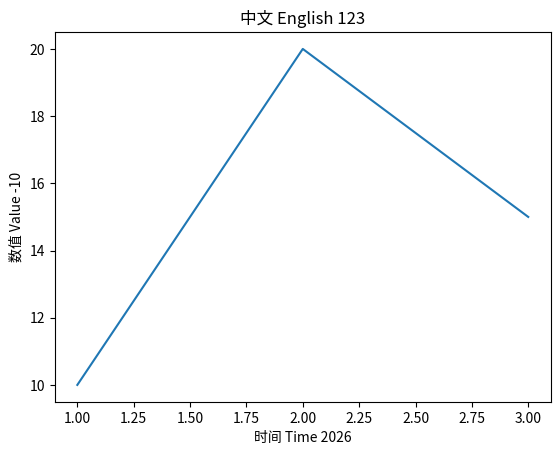

In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

In [7]:
import numpy as np
import math

np.random.seed(42)

# ========== 多头注意力 ==========
seq_len, d_model, num_heads = 4, 8, 2
head_dim = d_model // num_heads
print(f"模型维度: {d_model}, 头数: {num_heads}, 每头维度: {head_dim}")
print(f"验证: {num_heads} × {head_dim} = {num_heads * head_dim}")

X = np.random.randn(seq_len, d_model)


模型维度: 8, 头数: 2, 每头维度: 4
验证: 2 × 4 = 8


In [8]:
# 多个头各自独立的 W_q, W_k, W_v
W_q = np.random.randn(d_model, d_model)
W_k = np.random.randn(d_model, d_model)
W_v = np.random.randn(d_model, d_model)

Q = X @ W_q
K = X @ W_k
V = X @ W_v

# 按头切分: reshape 为 (seq_len, num_heads, head_dim)
Q_heads = Q.reshape(seq_len, num_heads, head_dim)
K_heads = K.reshape(seq_len, num_heads, head_dim)
V_heads = V.reshape(seq_len, num_heads, head_dim)

print(f"切分后 Q shape: {Q_heads.shape}")
print("每个头独立计算注意力 ↓")


切分后 Q shape: (4, 2, 4)
每个头独立计算注意力 ↓


In [9]:
# 每个头独立计算注意力
def softmax(x):
    x_shifted = x - x.max(axis=-1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

outputs = []
for h in range(num_heads):
    q = Q_heads[:, h, :]  # (seq_len, head_dim)
    k = K_heads[:, h, :]
    v = V_heads[:, h, :]

    scores = q @ k.T / math.sqrt(head_dim)
    weights = softmax(scores)
    out = weights @ v
    outputs.append(out)

    print(f"--- 头 {h} ---")
    print(f"注意力权重:\n{np.round(weights, 3)}\n")

# 拼接所有头的输出
multi_out = np.concatenate(outputs, axis=-1)
print(f"拼接后 shape: {multi_out.shape}")
print("多个头的输出拼接 → 再过一次线性投影 → 最终输出")


--- 头 0 ---
注意力权重:
[[0.    0.    0.    1.   ]
 [0.029 0.01  0.    0.961]
 [0.999 0.    0.    0.   ]
 [0.    0.787 0.213 0.   ]]

--- 头 1 ---
注意力权重:
[[0.    0.815 0.185 0.   ]
 [0.237 0.    0.011 0.753]
 [0.425 0.002 0.551 0.022]
 [0.035 0.007 0.    0.957]]

拼接后 shape: (4, 8)
多个头的输出拼接 → 再过一次线性投影 → 最终输出


In [10]:
# ========== 位置编码 ==========
max_len = 20
pos = np.arange(max_len).reshape(-1, 1)
dim = np.arange(d_model).reshape(1, -1)

# 正弦位置编码公式
PE = np.zeros((max_len, d_model))
PE[:, 0::2] = np.sin(pos / (10000 ** (dim[:, 0::2] / d_model)))
PE[:, 1::2] = np.cos(pos / (10000 ** (dim[:, 1::2] / d_model)))

print("位置编码矩阵 (前5个位置):")
print(np.round(PE[:5], 3))

print("\n✅ 每个位置都有独特的编码向量")
print("加到词向量上：X_encoded = X + PE[0:seq_len]")


位置编码矩阵 (前5个位置):
[[ 0.     1.     0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.95   0.1    1.     0.01   1.     0.001  1.   ]
 [ 0.909  0.807  0.199  0.998  0.02   1.     0.002  1.   ]
 [ 0.141  0.583  0.296  0.996  0.03   1.     0.003  1.   ]
 [-0.757  0.301  0.389  0.992  0.04   1.     0.004  1.   ]]

✅ 每个位置都有独特的编码向量
加到词向量上：X_encoded = X + PE[0:seq_len]


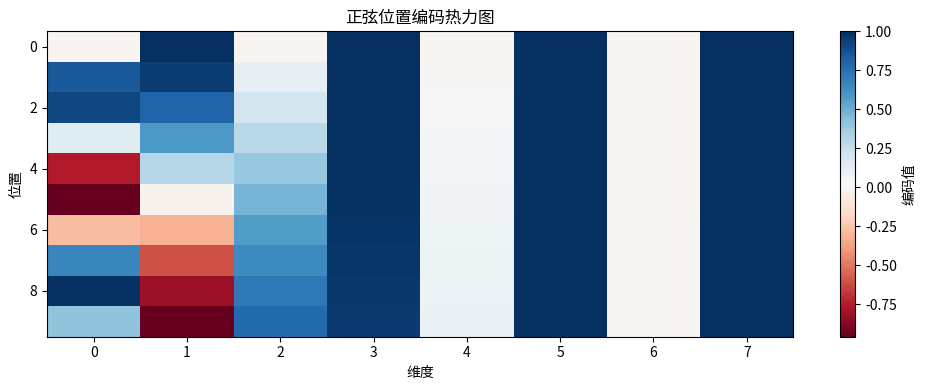

图表已保存为 positional_encoding.png


In [11]:
# 可视化位置编码
import matplotlib.pyplot as plt

# 解决中文显示乱码：设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 4))
plt.imshow(PE[:10], cmap='RdBu', aspect='auto')
plt.colorbar(label='编码值')
plt.xlabel('维度')
plt.ylabel('位置')
plt.title('正弦位置编码热力图')
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=100)  # 存文件
plt.show()                                        # 同时显示
print("图表已保存为 positional_encoding.png")


## 💡 业务关联思考

多头注意力在不同"头"关注不同模式——跟你分析糖水店时，同时关注**季节趋势、单品销量、原材料价格**多个维度一样，单看一个容易误判，多维度并行分析才全面。

---

> 💡 **进度: W1 Day 2/7 | 🤖 大模型**